# Plot all dv/v

This notebook will plot all the dv/v against water level changed published in the literature

In [151]:
!pip install pandas

## Read Meta analysis from literature

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data from the CSV file
df = pd.read_csv('data/seismic_gwl_data.csv')

# Calculate the medium of the frequency range
df['Seismic frequencies (Hz)'] = df['Seismic frequencies (Hz)'].apply(lambda x: sum(map(float, x.split('-'))) / 2)
df.head()

,Region,Waves used,Single vs array method,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),GWL estimate method,dv/v(%),Reference
0,Southern California,coda,array,1.1,16,NaN,Well,0.10,"Mao et al, 2022"
1,California,coda,single,6.0,6,NaN,Rainfall diffusion modeling,1.15,"Clements & Denolle, 2023"
2,Southern California - San Gabriel,coda,array,3.5,25,NaN,GW Well,0.15,"Clements and Denolle, 2018"
3,New Zealand Landslide,coda,Small array,7.0,2,NaN,Piezo @ seismometer borehole @ XM,2.00,"Voisin et al, 2016"
4,"Lyon, France",coda,Small array,3.5,2,NaN,Piezo,2.50,"Gaubert-Bastide et al, 2022"


In [153]:
import numpy as np

# Define constants
rho = 1000  # kg/m^3
g = 9.81  # m/s^2

# Convert Pore Pressure to GWL change where GWL change is NaN
df['GWL change (m)'] = df.apply(
    lambda row: float(row['Pore pressure (Pa)']) / (g * rho) if pd.isna(row['GWL change (m)']) and pd.notna(row['Pore pressure (Pa)']) else row['GWL change (m)'],
    axis=1
)

df.head()

,Region,Waves used,Single vs array method,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),GWL estimate method,dv/v(%),Reference
0,Southern California,coda,array,1.1,16,NaN,Well,0.10,"Mao et al, 2022"
1,California,coda,single,6.0,6,NaN,Rainfall diffusion modeling,1.15,"Clements & Denolle, 2023"
2,Southern California - San Gabriel,coda,array,3.5,25,NaN,GW Well,0.15,"Clements and Denolle, 2018"
3,New Zealand Landslide,coda,Small array,7.0,2,NaN,Piezo @ seismometer borehole @ XM,2.00,"Voisin et al, 2016"
4,"Lyon, France",coda,Small array,3.5,2,NaN,Piezo,2.50,"Gaubert-Bastide et al, 2022"


In [154]:
# Split the range values and take the mean
df['GWL change (m)'] = df['GWL change (m)'].apply(lambda x: np.mean(list(map(float, x.split('-')))) if '-' in str(x) else float(x))

df.describe()

,Seismic frequencies (Hz),GWL change (m),Pore pressure (Pa),dv/v(%)
count,19.000000,19.000000,3.000000,19.000000
mean,4.752632,10.892642,9233.333333,0.962105
std,5.437728,22.996303,13711.430754,0.999709
min,0.245000,0.010194,100.000000,0.010000
25%,0.600000,0.450000,1350.000000,0.100000
50%,3.500000,2.500000,2600.000000,0.400000
75%,6.750000,9.500000,13800.000000,2.000000
max,21.500000,100.000000,25000.000000,2.500000


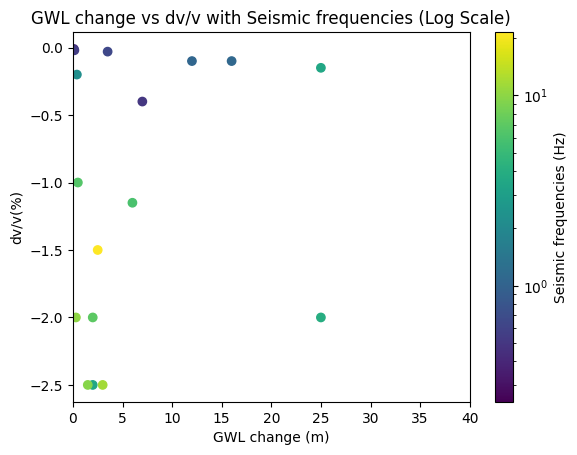

In [155]:
from matplotlib.colors import LogNorm

# Plot the data with a log scale for the color
plt.scatter(df['GWL change (m)'], -df['dv/v(%)'], c=df['Seismic frequencies (Hz)'], cmap='viridis', norm=LogNorm())
plt.colorbar(label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)')
plt.ylabel('dv/v(%)')
plt.xlim(0, 40)
plt.title('GWL change vs dv/v with Seismic frequencies (Log Scale)')
plt.show()

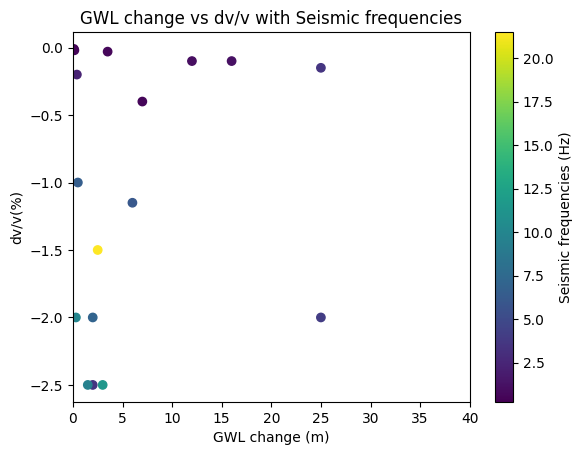

In [156]:

# Plot the data
plt.scatter(df['GWL change (m)'], -df['dv/v(%)'], c=df['Seismic frequencies (Hz)'], cmap='viridis')
plt.colorbar(label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)')
plt.ylabel('dv/v(%)')
plt.xlim(0, 40)
plt.title('GWL change vs dv/v with Seismic frequencies')
plt.show()

### add Garambois' data

In [157]:
# Read the data from the CSV file
garambois_df = pd.read_csv('data/garambois19_digitized.csv')
garambois_df.describe()

,dvv(%),GWL change (m)
count,30.000000,30.000000
mean,0.032833,0.056704
std,0.547183,0.937520
min,-0.779809,-1.431211
25%,-0.443929,-0.726335
50%,0.066141,0.010421
75%,0.489108,0.862295
max,0.937596,1.494559


/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_68363/3994988710.py:60: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,150)


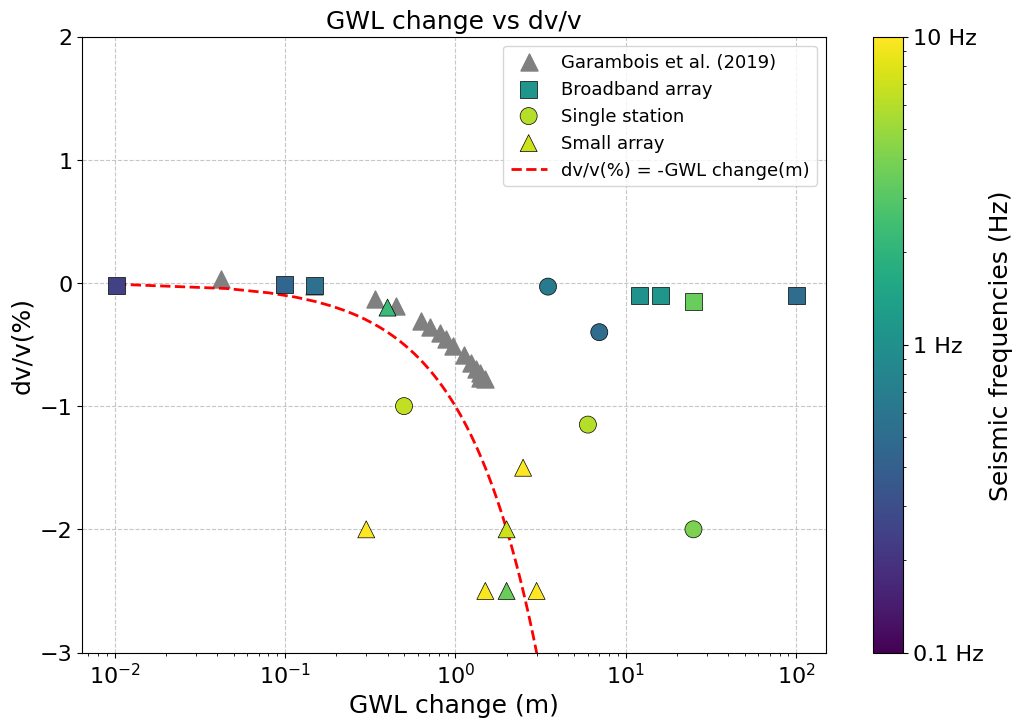

In [173]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define marker styles for each category
marker_styles = {
    'array': 's',  # square
    'single': 'o',  # circle
    'Small array': '^'  # triangle
}


plt.figure(figsize=(12,8))

# Set fixed bounds for the colorbar
vmin = 0.1  # Minimum value for the color scale
vmax = 10  # Maximum value for the color scale

# add the garambois data as gray scatter points
plt.scatter(garambois_df['GWL change (m)'], garambois_df['dvv(%)'],\
            marker='^',s=150, color='gray', label='Garambois et al. (2019)', zorder=2)

# Create a scatter plot with different markers
for category, marker in marker_styles.items():
    subset = df[df['Single vs array method'] == category]
    if category=='array':
        cat2 = 'Broadband array'
    elif category == 'single':
        cat2 = 'Single station'
    else:
        cat2 = category
    sc = plt.scatter(subset['GWL change (m)'], -subset['dv/v(%)'], 
                c=subset['Seismic frequencies (Hz)'], cmap='viridis', 
                norm=LogNorm(vmin=vmin, vmax=vmax), marker=marker, label=cat2,
                edgecolor='k', linewidth=0.5,s=150,zorder=3)

# Add colorbar with custom ticks for octaves
cbar = plt.colorbar(sc)
cbar.set_label('Seismic frequencies (Hz)',fontsize=18)

# Define octave frequencies (example values, adjust as needed)
octave_frequencies = [0.1,1,10]
cbar.set_ticks(octave_frequencies)
cbar.set_ticklabels([f'{freq} Hz' for freq in octave_frequencies],fontsize=16)


# Fit a linear model to the data
x= df[df['GWL change (m)']<5]['GWL change (m)']
# Plot the linear reference line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = -x_fit
plt.plot(x_fit, y_fit, color='red', linestyle='--', linewidth=2, label='dv/v(%) = -GWL change(m)', zorder=2)


# plt.colorbar(sc, label='Seismic frequencies (Hz)')
plt.xlabel('GWL change (m)',fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel('dv/v(%)',fontsize=18)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlim(0,150)
plt.title('GWL change vs dv/v',fontsize=18)
plt.ylim(-3, 2)

plt.legend(fontsize=13,loc='best')
plt.grid(True,zorder=1, linestyle='--',alpha=0.7)
plt.savefig('./plots/GWL_change_vs_dv_v.png', dpi=500)
plt.show()

## Read Mao et al, 2022 data

In [159]:
from scipy.io import loadmat

# Load the .mat file
mat_data = loadmat('data/MaoS_2022NC_fig2b.mat')

/Users/marinedenolle/opt/miniconda3/envs/czseis/lib/python3.10/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab._mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [160]:

# Extract the data into a numpy array
# Assuming the variable name in the .mat file is 'data', adjust accordingly
gwl_data = mat_data['waterlevel']
dvv_data = mat_data['dvov']
dvv_data = dvv_data.flatten()
gwl_data = gwl_data.flatten()
# demean gwl_data
gwl_data = gwl_data - np.mean(gwl_data)
dvv_data = dvv_data - np.mean(dvv_data)

In [161]:
from scipy.signal import resample

# Smooth the dvv_data using a narrow Gaussian filter
# smoothed_dvv_data = gaussian_filter1d(dvv_data, sigma=1)

# Downsample the smoothed dvv_data to match the length of gwl_data
downsampled_dvv_data = resample(dvv_data, len(gwl_data))

# Reshape to match the original shape
# downsampled_dvv_data = downsampled_dvv_data.reshape(-1, 1)


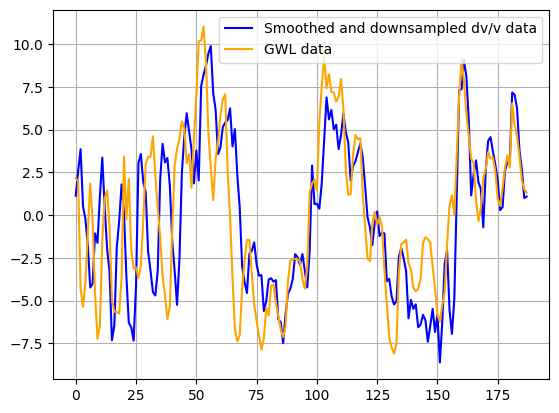

In [162]:
# now plot the two arrays together in two different colors
plt.plot(-downsampled_dvv_data*1.5e4, label='Smoothed and downsampled dv/v data',color='blue')
plt.plot(gwl_data, label='GWL data', color='orange')
plt.legend()
plt.grid(True)
plt.show()


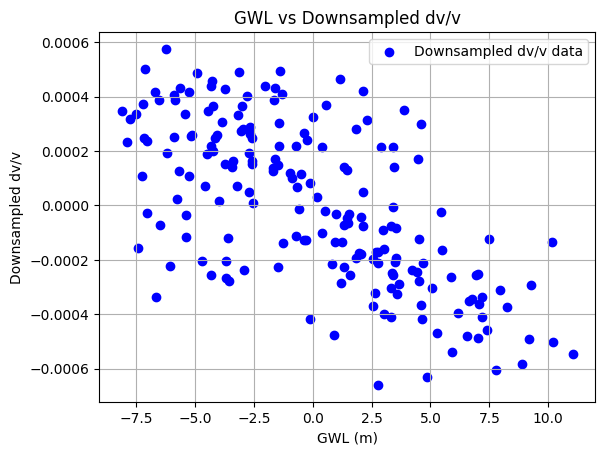

In [163]:
plt.scatter(gwl_data, downsampled_dvv_data, c='blue', label='Downsampled dv/v data')
plt.xlabel('GWL (m)')
plt.ylabel('Downsampled dv/v')
plt.title('GWL vs Downsampled dv/v')
plt.legend()
plt.grid(True)
plt.show()

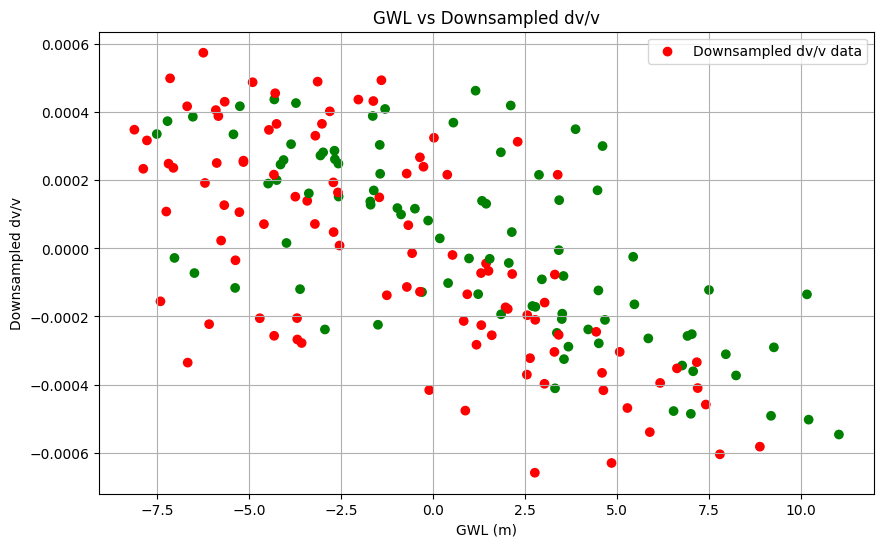

In [164]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gwl_data and downsampled_dvv_data are already defined

# Calculate the difference between consecutive GWL values
gwl_diff = np.diff(gwl_data, prepend=gwl_data[0])

# Create a color array based on the difference
colors = np.where(gwl_diff > 0, 'green', 'red')

# Plot the scatter plot with different colors for increasing and decreasing GWL
plt.figure(figsize=(10, 6))
plt.scatter(gwl_data, downsampled_dvv_data, c=colors, label='Downsampled dv/v data')
plt.xlabel('GWL (m)')
plt.ylabel('Downsampled dv/v')
plt.title('GWL vs Downsampled dv/v')
plt.legend()
plt.grid(True)
plt.show()

In [165]:
gwl_data = gwl_data.flatten()
print(gwl_data.shape)

(188,)


In [166]:
gwl_data.shape

(188,)

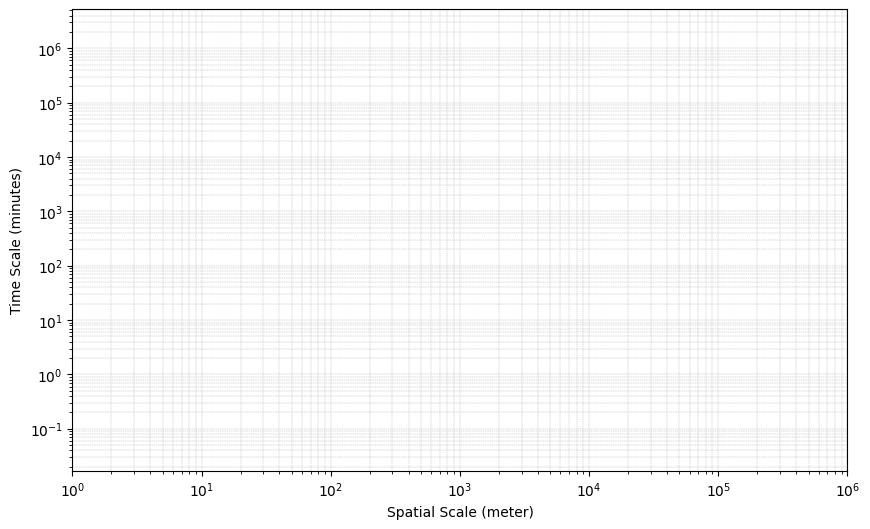

In [167]:
# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Set the x-axis and y-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# Set the limits for the x-axis and y-axis
ax.set_xlim(1, 1e6)  # 1 meter to 1000 kilometers
ax.set_ylim(1/60, 60*24*365*10)  # 1 minute to 10 years (in minutes)

# Set the labels for the x-axis and y-axis
ax.set_xlabel('Spatial Scale (meter)')
ax.set_ylabel('Time Scale (minutes)')

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.3)

# Show the plot
plt.savefig('./plots/Time_vs_Spatial_Scale.png', dpi=500)
plt.show()

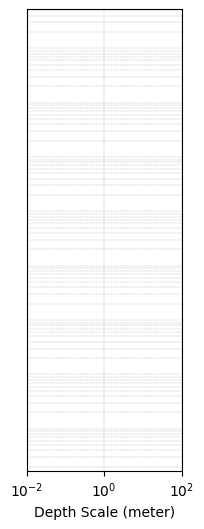

In [168]:
# Create a new figure and axis
fig, ax = plt.subplots(figsize=(2, 6))

# Set the x-axis and y-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# Set the limits for the x-axis and y-axis
ax.set_xlim(0.01, 100)  # 1 cm to 100 m
ax.set_ylim(1/60, 60*24*365*10)  # 1 minute to 10 years (in minutes)

# Set the labels for the x-axis and y-axis
ax.set_xlabel('Depth Scale (meter)')
# ax.set_ylabel('Time Scale (minutes)')
# remove y-axis label
ax.set_yticklabels([])
# remove outside ticks
ax.tick_params(axis='y', which='both', left=False, right=False)

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.3)

# Show the plot
plt.savefig('./plots/Time_vs_Depth_Scale.png', dpi=500)
plt.show()